## Linear inter- & extrapolation
1D linear inter- and extrapolation, multiple y-data possible.

credit to [Loren Shure (The MathWorks)](http://blogs.mathworks.com/loren/2008/08/25/piecewise-linear-interpolation/) and [Jose M. Mier](https://de.mathworks.com/matlabcentral/fileexchange/43325-quicker-1d-linear-interpolation-interp1qr)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def interpextraplin(x,y,xi):
    """
    1D linear inter- and extrapolation, multiple y-data possible
    x:  x-data vector [m], monotonically increasing
    y:  y-data matrix [m x n], corresponding to x (interpolation for each column)
    xi: x-value vector [p] to be interpolated, in any order
    Loren Shure (The MathWorks) http://blogs.mathworks.com/loren/2008/08/25/piecewise-linear-interpolation/
    Jose M. Mier, https://de.mathworks.com/matlabcentral/fileexchange/43325-quicker-1d-linear-interpolation-interp1qr """
    # slope of line segments
    if y.ndim ==1:
        m  = np.diff(y)/np.diff(x)
    elif y.ndim ==2:
        m  = np.diff(y,axis=0)/np.diff(x)[:, np.newaxis]
    ind = np.sum( xi > x[:, np.newaxis], axis=0) - 1    # find interval
    ind = np.maximum(ind, 0)            # avoid index smaller 0
    ind = np.minimum(ind, len(x)-2)     # avoid index larger than len(x)-2
    # inter- & extrapolation
    if y.ndim ==1:
        yi = m[ind]*(xi-x[ind]) + y[ind]
    elif y.ndim ==2:
        yi = m[ind,:]*(xi[:, np.newaxis]-x[ind, np.newaxis]) + y[ind,:]
    return yi   # interpolated values matrix [p x n], corresponding to xi

- input

In [3]:
Nx  = 5   # number of data points
Nxi = 3   # number of query points

- test data

In [4]:
x = np.linspace(0,800,Nx)
y = x**3/1e3
# y = np.column_stack(( x**2, x**3/1e3))  # does not work for np.interp

xi = np.linspace(-50,900,Nxi)

- interpolation

In [5]:
yi    = interpextraplin(x,y,xi)
yi_np = np.interp(xi, x, y)

- plot

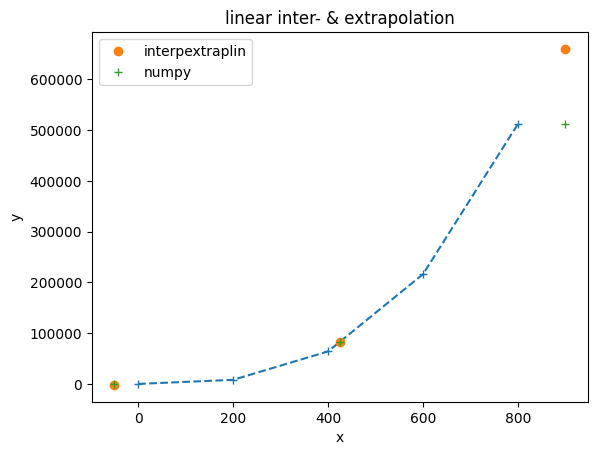

In [6]:
plt.plot(x,y,'--+')
plt.plot(xi,yi,'o',label='interpextraplin')
plt.plot(xi,yi_np,'+',label='numpy')
plt.legend()
plt.title('linear inter- & extrapolation')
plt.xlabel('x')
plt.ylabel('y')
plt.show()